# 02 - Preprocessing, Distortion Correction, and Vessel Mask QC

This notebook starts from the motion-corrected Zarr movie and evaluates the preprocessing stage: intensity correction, distortion correction, crop refinement, normalization, and vessel-mask extraction.

In [15]:
%matplotlib inline
import os, sys
from pathlib import Path

# Locate the repository root from the current notebook working directory.
def find_repo_root(start):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "Airscope_ca").is_dir() and (path / "configs").is_dir():
            return path
    raise RuntimeError(f"Could not find repo root from {start}")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))

DATA_PATH = "/mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames"
OUT_PATH = DATA_PATH.replace("frames", "Analysis")
print(f"REPO_ROOT : {REPO_ROOT}")
print(f"DATA_PATH : {DATA_PATH}")
print(f"OUT_PATH  : {OUT_PATH}")


REPO_ROOT : /data/home/angran/BBNC/code/PICO_ca_processing_release
DATA_PATH : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames
OUT_PATH  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis


In [16]:
# Compose a reproducible Hydra config for this notebook run.
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(
        config_name="config",
        overrides=[
            f"data_path={DATA_PATH}",
            f"out_path={OUT_PATH}",
            "motion=suite2p",
            "rmbg=ddp",
        ],
    )

print(OmegaConf.to_yaml(cfg))

motion:
  fr: 10
  mc_chunk_size: 1000
  zarr_chunk_size: 1000
  method: suite2p
  device: cuda
  suite2p:
    align_by_chan2: false
    nimg_init: 400
    maxregshift: 0.1
    do_bidiphase: false
    bidiphase: 0.0
    batch_size: 100
    nonrigid: true
    maxregshiftNR: 5
    block_size:
    - 128
    - 128
    smooth_sigma_time: 0
    smooth_sigma: 1.15
    spatial_taper: 3.45
    th_badframes: 1.0
    norm_frames: true
    snr_thresh: 1.2
    subpixel: 10
    two_step_registration: false
    reg_tif: false
    reg_tif_chan2: false
preprocessing:
  crop_parameter:
  - 153
  - 303
  - 1000
  - 1000
  intensity_corr_flag: false
  bad_frame_detect_flag: false
  preprocess_workers: 64
  preprocess_chunk_size: 512
  zarr_chunk_size: 500
rmbg:
  up_sample: 2
  rmbg_chunk_size: 1000
  zarr_chunk_size: 500
  rmbg_gsize: 6
  batch_size: 8
  print_interval: 20
  use_amp: true
  copy_interval: 4
  num_process_per_gpu: 2
  ckpt_pth: ckpt/background_rejection_ckpt_resize_2.pth
  device: cuda
  

In [17]:
# Imports used by this notebook only.
import os
import logging
from pathlib import Path

import numpy as np

from Airscope_ca.process_script import build_paths, setup_logger
from Airscope_ca.pipeline import get_frame_count, preprocess_movie
from Airscope_ca.utils.io_videos import open_zarr_array
from airscope_notebook_tools import (
    set_publication_style,
    plot_frame_montage,
    plot_projection_panel,
    overlay_mask,
    display_existing_image,
    list_stage_outputs,
)

set_publication_style()
os.makedirs(OUT_PATH, exist_ok=True)
paths = build_paths(cfg)
logger = setup_logger(OUT_PATH)
logger.addHandler(logging.StreamHandler())

frame_count = get_frame_count(cfg)
print(f"Frame count: {frame_count}")
print(f"MC zarr    : {paths.mc_zarr_path}")
print(f"Pre zarr   : {paths.preprocess_zarr_path}")
print(f"RMBG zarr  : {paths.rmbg_zarr_path}")
print(f"Seg out    : {paths.seg_out}")


     7447819 [process_script.py:        setup_logger():87] [2656966] Logging INFO and above from root logger to /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/log_file.log


4000
Frame count: 4000
MC zarr    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc/motion_corrected.zarr
Pre zarr   : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/preprocess/video_preprocessed.zarr
RMBG zarr  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr
Seg out    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1


## 1. Load Motion-Corrected Input

In [18]:
# Load the motion-corrected movie produced by notebook 01.
mc_arr = open_zarr_array(paths.mc_zarr_path, mode="r")

## 2. Run Preprocessing

=======>do upsampling<=======

     7477332 [stage_preprocessing.py:    preprocess_movie():69] [2656966] =======>do upsampling<=======

=======>field distortion correction and intensity uniformity<=======

     7477405 [stage_preprocessing.py:    preprocess_movie():87] [2656966] =======>field distortion correction and intensity uniformity<=======

Former crop_parameter is [153, 303, 1000, 1000]
     7477407 [stage_preprocessing.py:    preprocess_movie():88] [2656966] Former crop_parameter is [153, 303, 1000, 1000]


crop parameter pre [64, 329, 1000, 1000]

0: 480x640 1 ROI, 6.7ms
Speed: 2.4ms preprocess, 6.7ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
crop parameter yolo: [50, 404, 1000, 1000]


Corrected crop_parameter is as follows: [50, 404, 1000, 1000]
     7481721 [stage_preprocessing.py:    preprocess_movie():99] [2656966] Corrected crop_parameter is as follows: [50, 404, 1000, 1000]
=======>preprocess frames with 64 workers<=======

     7481724 [stage_preprocessing.py:    preprocess_movie():102] [2656966] =======>preprocess frames with 64 workers<=======

normalize: 100%|██████████| 8/8 [02:54<00:00, 21.79s/it]
=======>save preprocessed video to Zarr: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/preprocess/video_preprocessed.zarr<=======

     7913922 [stage_preprocessing.py:    preprocess_movie():119] [2656966] =======>save preprocessed video to Zarr: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/preprocess/video_preprocessed.zarr<=======

100%|██████████| 8/8 [01:13<00:00,  9.19s/it]
=======>get vessel mask<=======

     8038155 [stage_preprocessing.py:    preprocess_movie():125] [2656966] =======>get vessel mask<=======



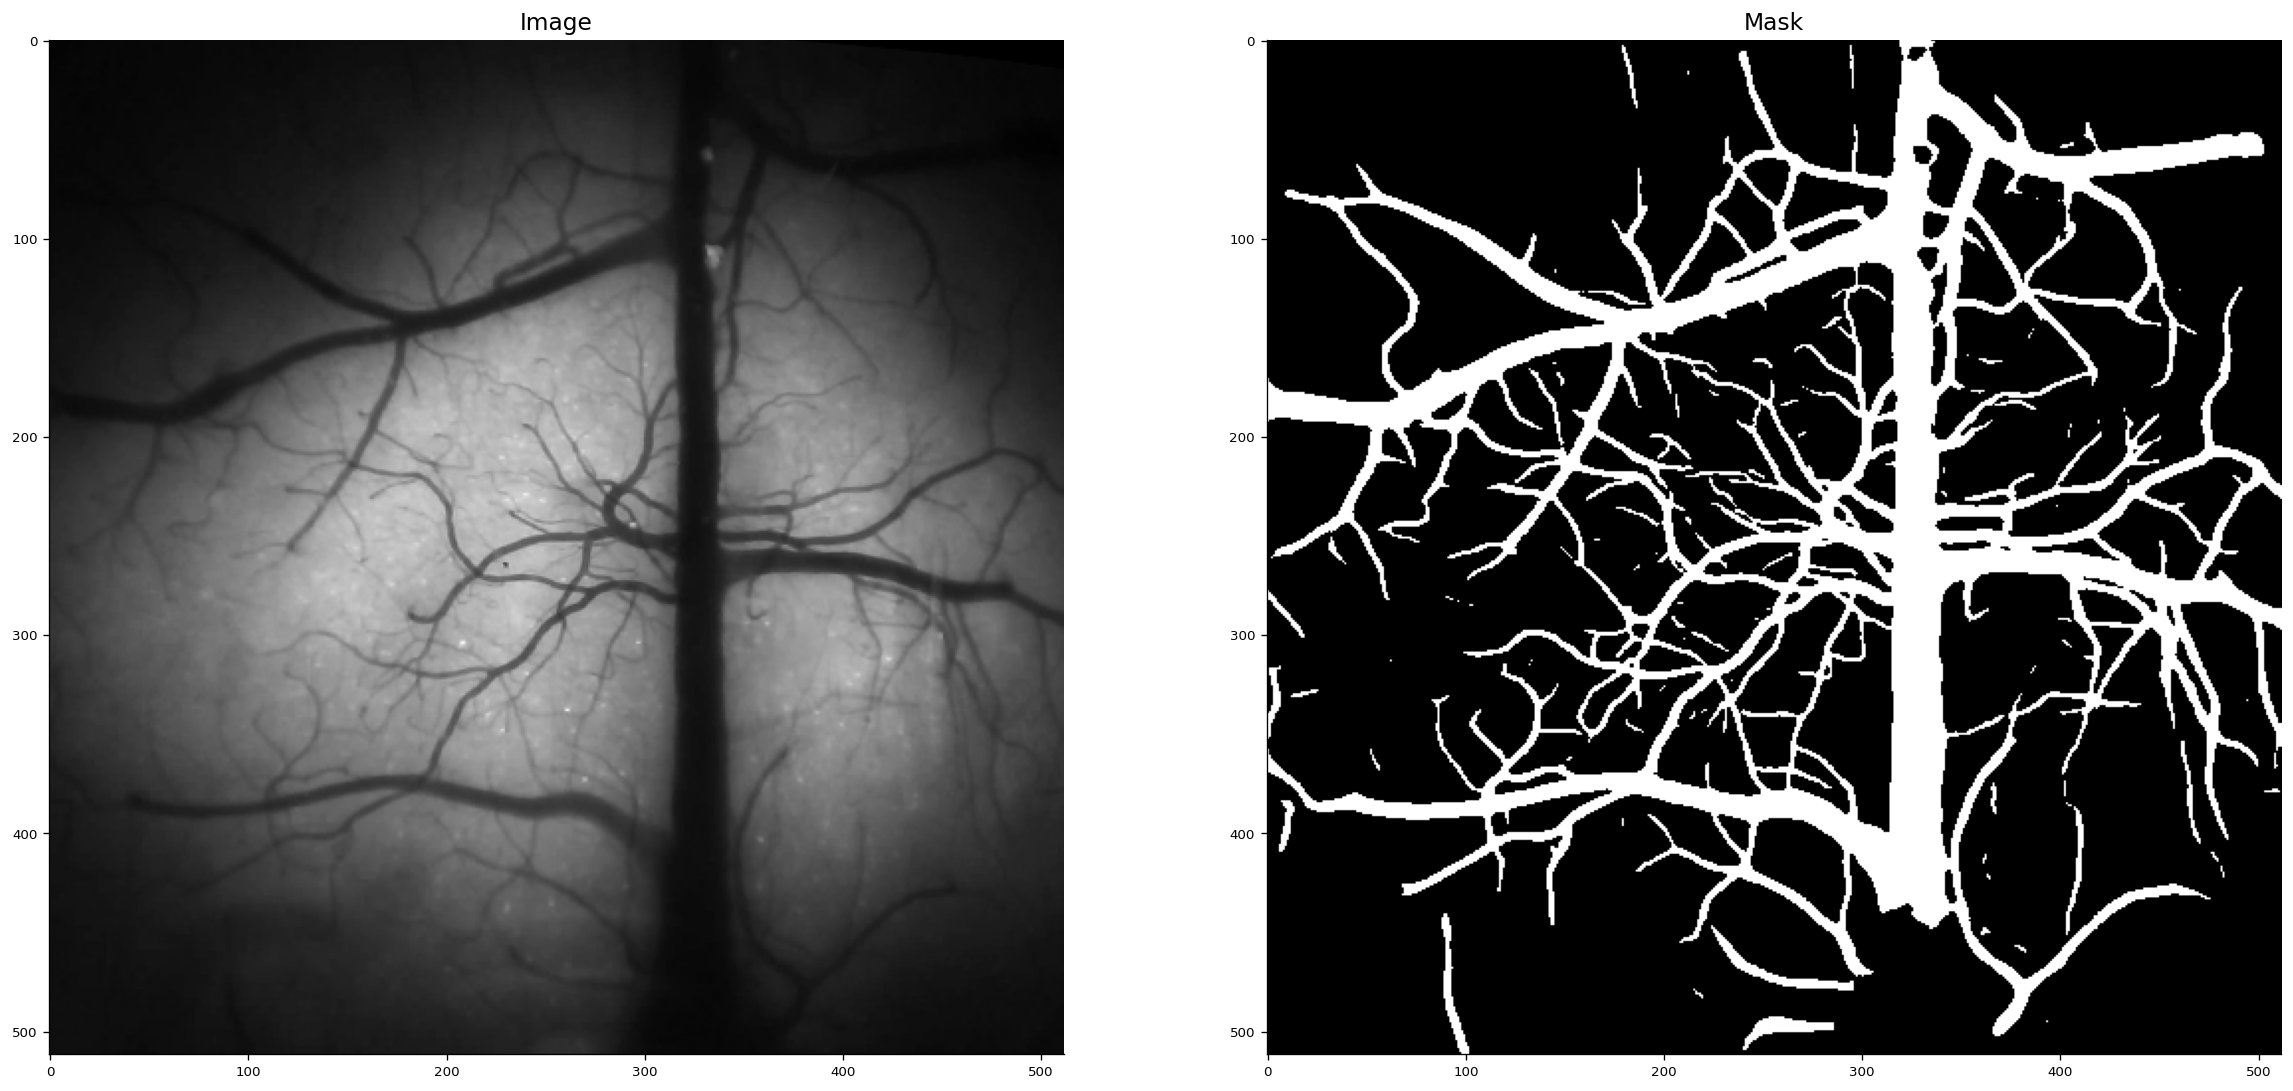

video_preprocessed: ndarray (4000, 2000, 2000), uint8
     8041528 [stage_preprocessing.py:    preprocess_movie():136] [2656966] video_preprocessed: ndarray (4000, 2000, 2000), uint8
vessel_mask: dtype float32, min 0.0, max 1.0
     8041530 [stage_preprocessing.py:    preprocess_movie():137] [2656966] vessel_mask: dtype float32, min 0.0, max 1.0


vessel_img  shape: (512, 512)
vessel_mask shape: (512, 512)
preprocessed zarr: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/preprocess/video_preprocessed.zarr


In [19]:
# Materialize the Zarr movie because preprocessing currently expects an in-memory array.
video = np.asarray(mc_arr)
vessel_img, vessel_mask = preprocess_movie(cfg, video, paths, logger)
del video
print(f"vessel_img  shape: {vessel_img.shape}")
print(f"vessel_mask shape: {vessel_mask.shape}")
print(f"preprocessed zarr: {paths.preprocess_zarr_path}")

ROI cropping by YOLO


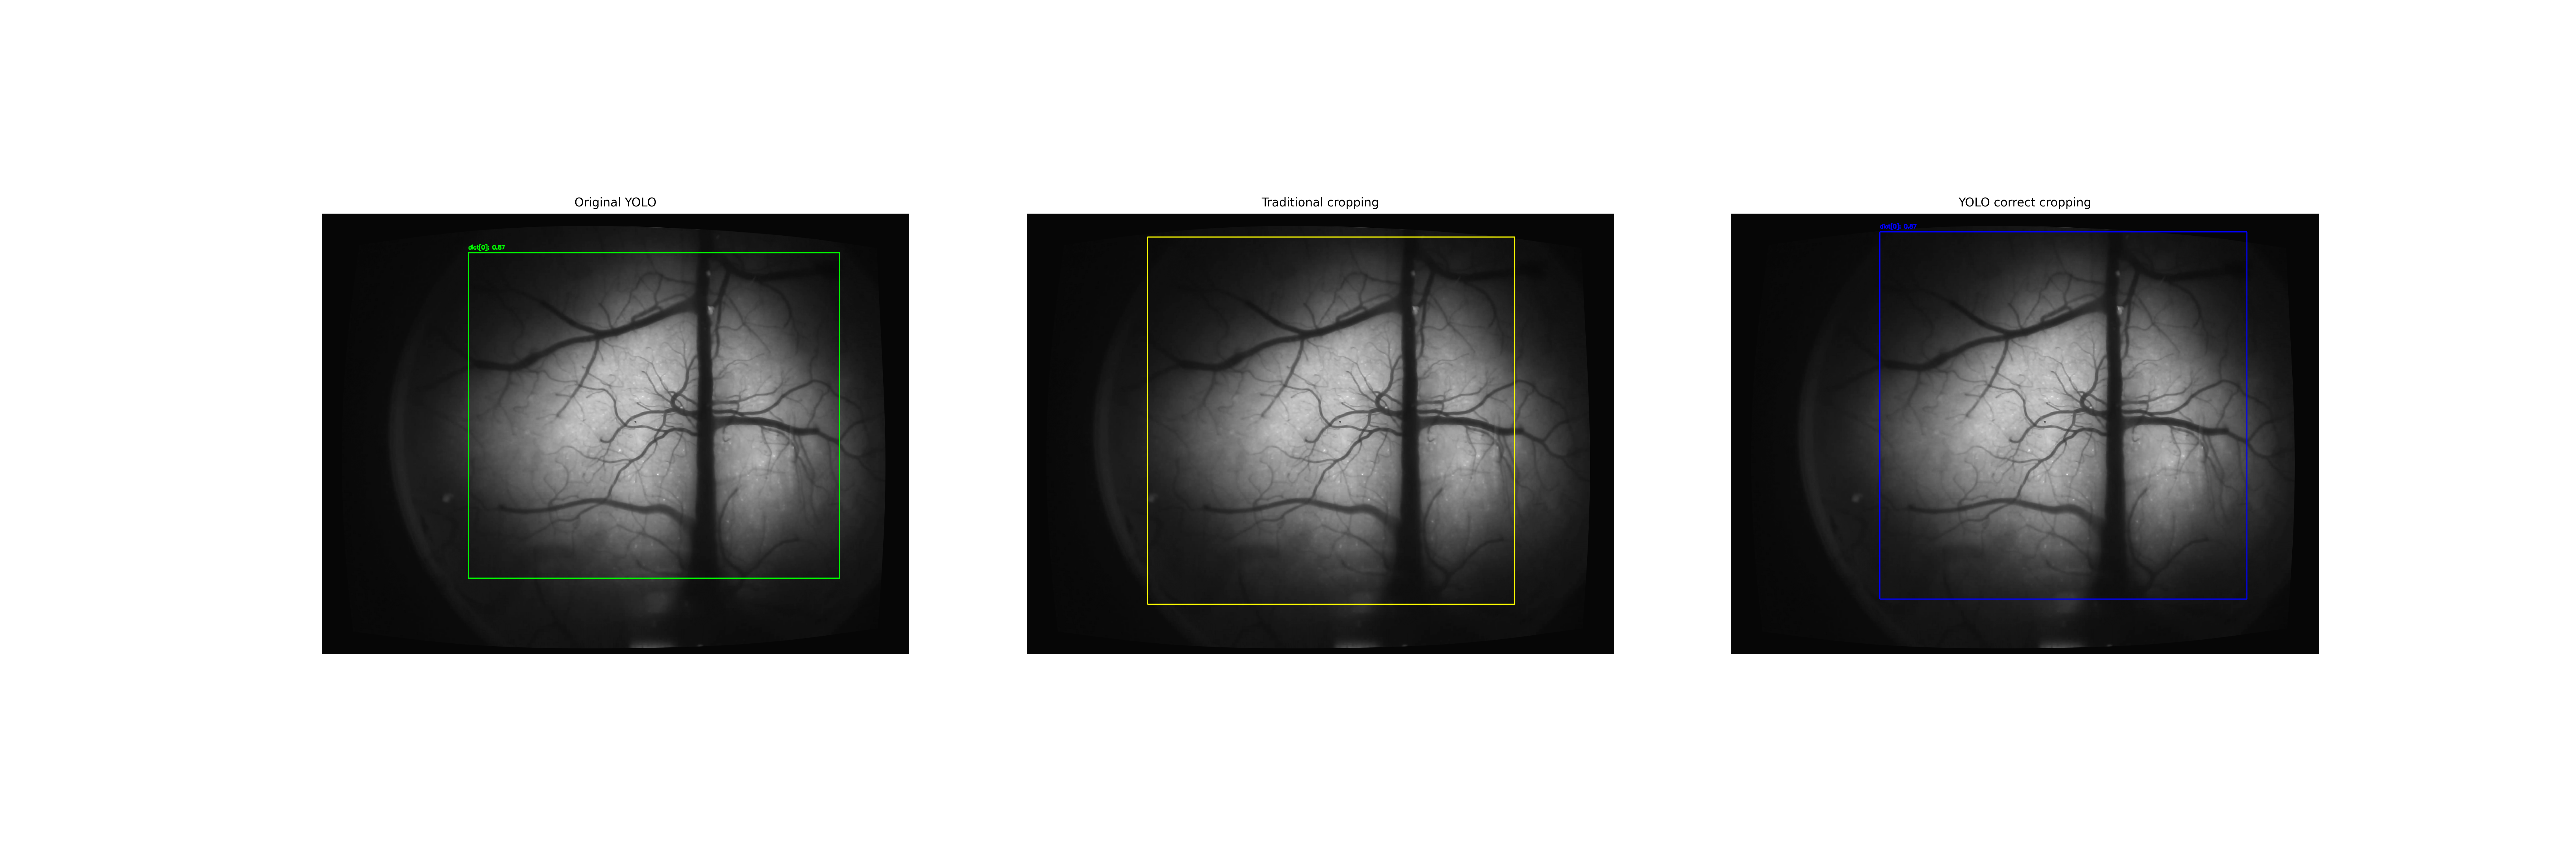

In [20]:
# Inspect the automated crop selected by YOLO, when the figure is available.
display_existing_image(Path(OUT_PATH) / "YOLO_ROI.png", title="ROI cropping by YOLO")

## 3. Preprocessed Movie QC

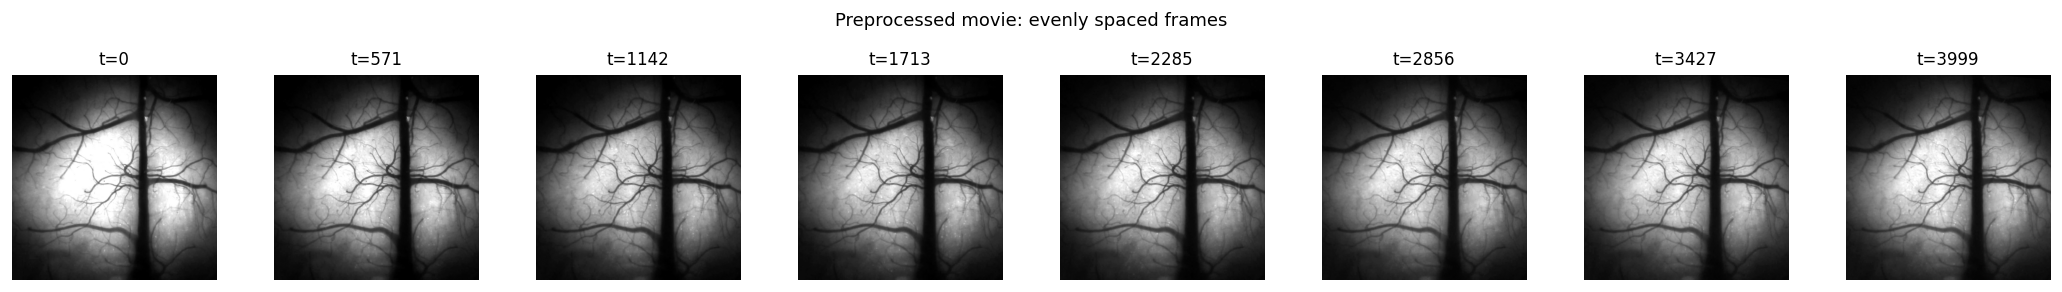

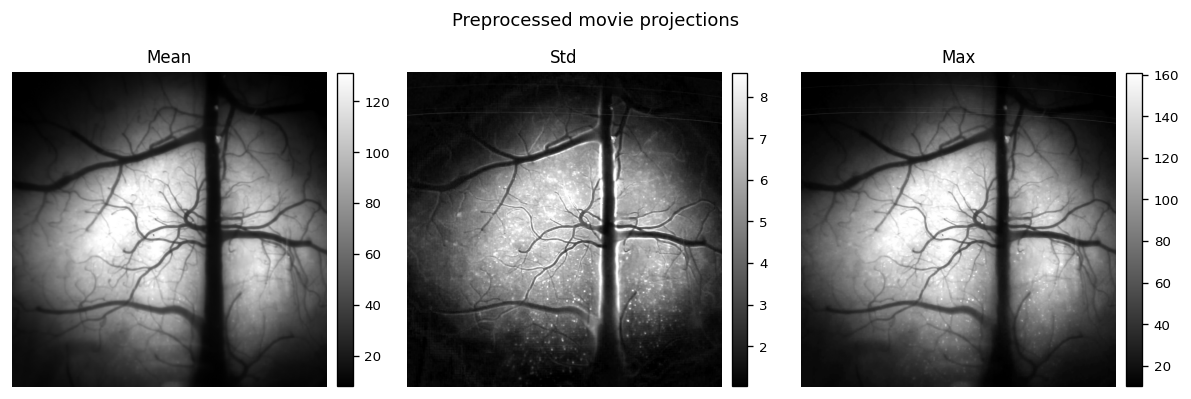

In [21]:
# Reopen the saved preprocessed movie for QC and downstream reproducibility.
pre_arr = open_zarr_array(paths.preprocess_zarr_path, mode="r")
_ = plot_frame_montage(pre_arr, n=8, title="Preprocessed movie: evenly spaced frames")
_ = plot_projection_panel(pre_arr, title="Preprocessed movie projections", n_samples=128)

## 4. Vessel Image and Mask Review

Output directory: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis
YOLO_ROI.png
badframe_replaced.avi
mc.avi
preprocessed.avi
rmbg.avi
vessel_image.tif
vessel_mask.png
vessel_mask.tif
vessel_mask_clean.tif
vessel_mask_dilate.tif


[PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/YOLO_ROI.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/badframe_replaced.avi'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc.avi'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/preprocessed.avi'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg.avi'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/vessel_image.tif'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/vessel_mask.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/vessel_mask.tif'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/vessel_mask_clean.tif'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/vessel_mask_dilate.tif')]

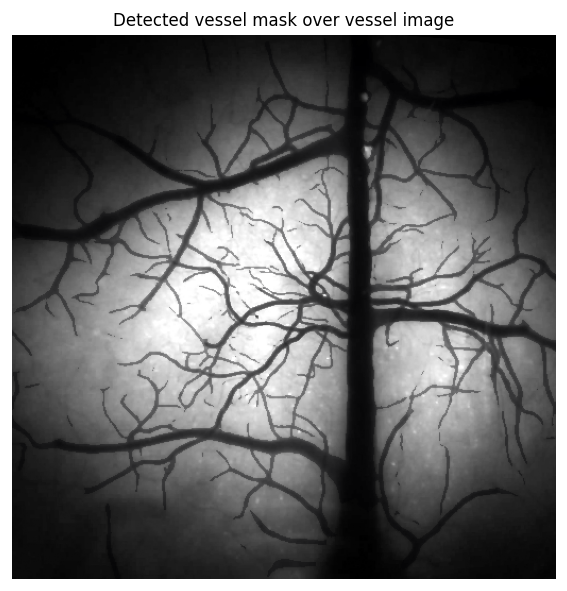

In [23]:
# Overlay vessel mask on the vessel image and list saved preprocessing artifacts.
_ = overlay_mask(vessel_img, vessel_mask, title="Detected vessel mask over vessel image")
list_stage_outputs(paths.out_path, patterns=("vessel*.png", "vessel*.tif", "YOLO*.png", "*.avi"), max_items=40)